In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt 

## Forming expectations from a distribution
Let's start with a data generator that simulates restaurant ratings (1 star to 5 stars), which we can draw samples from. 

In [2]:
# Set the random seed for reproducibility
rng = np.random.default_rng(2)

def restaurant_ratings_generator(a = 1, n = 500, loc = 1, scale = 1):
    samples = stats.skewnorm.rvs(a, size=n, loc=loc, scale = scale, random_state=rng)
    samples = np.round(samples)
    samples = np.clip(samples, 1, 5)
    return samples

def plot_ratings(ratings, restaurant_name):
    bins=[-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5]
    title_str = restaurant_name + ' Ratings'
    plt.hist(ratings,bins)
    plt.xticks(range(6))
    plt.xlim([1, 6])
    plt.xlabel('Rating')
    plt.ylabel('Frequency')
    plt.title(title_str)
    plt.show()

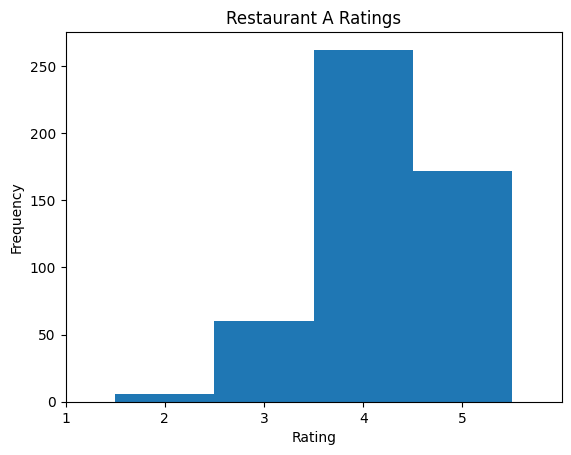

4.2

In [3]:
restaurant_a_ratings = restaurant_ratings_generator(a = -4, n = 500, loc = 5)
plot_ratings(restaurant_a_ratings, "Restaurant A")
restaurant_a_ratings.mean()


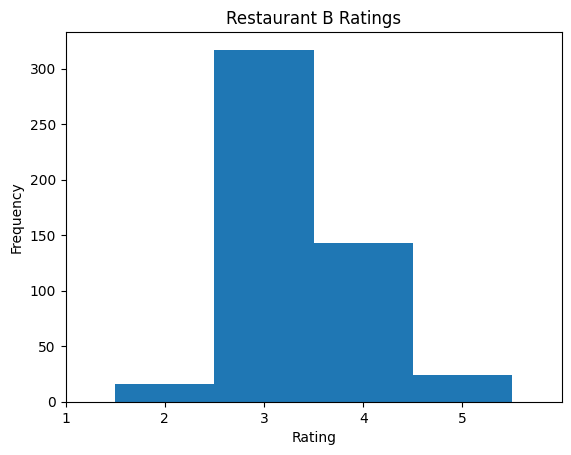

In [4]:
restaurant_b_ratings = restaurant_ratings_generator(a = 10, n = 500, loc = 2.5)
plot_ratings(restaurant_b_ratings, "Restaurant B")

Which restaurant would you rather eat at? How did you decide this?

## Generating summary statistics about a distribution
Visually inspecting a distribution is a crucial step for understanding dating. We can formalize some of the big patterns using summary statistics.

In [5]:
n_observations = restaurant_a_ratings.size
minimum_rating = np.min(restaurant_a_ratings)
maximum_rating = np.max(restaurant_a_ratings)
mean_rating = np.mean(restaurant_a_ratings)

# print these values with text
print(f"Number of observations: {n_observations}")
print(f"Minimum rating: {minimum_rating}")
print(f"Maximum rating: {maximum_rating}")
print(f"Mean rating: {mean_rating}")


Number of observations: 500
Minimum rating: 2.0
Maximum rating: 5.0
Mean rating: 4.2


In [6]:
stats.describe(restaurant_a_ratings)

DescribeResult(nobs=500, minmax=(2.0, 5.0), mean=4.2, variance=0.47294589178356705, skewness=-0.5032770846901479, kurtosis=0.014938236139041106)

In [7]:
stats.describe(restaurant_b_ratings)

DescribeResult(nobs=500, minmax=(2.0, 5.0), mean=3.35, variance=0.3882765531062124, skewness=0.7804182640820403, kurtosis=0.4805827263267419)

## Choosing the right descriptive statistics
Sometimes, we have to be careful when choosing the statistic that is appropriate to describe our data. Consider a very long-tailed distribution:

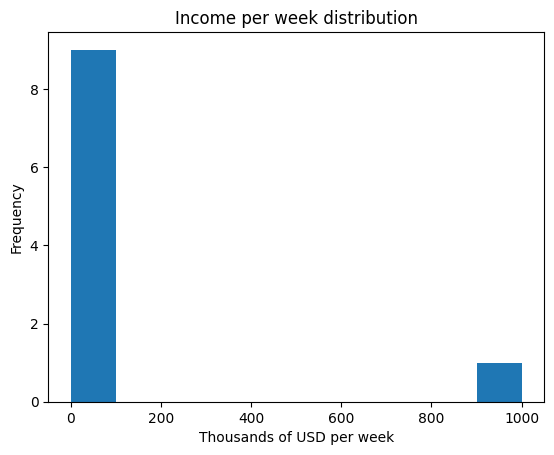

In [8]:
# Generate samples from a power law distribution
neighbor_earnings  = stats.lognorm.rvs(s=1, size = 9, random_state = rng)
millionaire_earnings = np.array([1000])
income = np.append(neighbor_earnings, millionaire_earnings)

# Plot the histogram of the samples
plt.hist(income)
plt.xlabel('Thousands of USD per week')
plt.ylabel('Frequency')
plt.title('Income per week distribution')
plt.show()

In [9]:
mean_income = np.mean(income)
median_income = np.median(income)

print(f"Mean income: {mean_income}")
print(f"Median income: {median_income}")

Mean income: 103.42678479662474
Median income: 3.2403019005955738


Which is more appropriate to describe a _typical_ value of income?